In [110]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
from sklearn.svm import SVC, LinearSVC
import re 
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")   

In [111]:
df = pd.read_csv("winter_project_2026/development.csv")

category_map = {
    0: "International News",
    1: "Business",
    2: "Technology",
    3: "Entertainment",
    4: "Sports",
    5: "General News",
    6: "Health"
}

print(df.dtypes)
print(df.shape)

Id            int64
source       object
title        object
article      object
page_rank     int64
timestamp    object
label         int64
dtype: object
(79997, 7)


In [112]:
#remove nan

df.dropna(inplace=True)
df.isna().sum().sum()
print(df.shape)

(79995, 7)


In [ ]:
def clean_text_without_url(text):
    if not isinstance(text, str):
        return ""

    # capturing alt captions from HTML before stripping tags
    captions = " ".join(re.findall(r'alt="([^"]*)"', text))
    captions = re.sub(r'[^a-zA-Z\s]', ' ', captions)

    # removing the URL messages 
    text_no_links = re.sub(r'https?://\S+', ' ', text)

    # remove HTML tags
    text_without_tags = re.sub(r'<[^>]+>', ' ', text_no_links)

    # keep information about money simbols
    text_without_tags = re.sub(
        r'[$€£¥]',
        ' MONEYAMOUNT ',
        text_without_tags
    )

    # this removes punctuation, numbers
    text_final = re.sub(r"[^a-zA-Z\s]", ' ', text_without_tags)

    combined = text_final  + " " + captions

    # lower casse and extra whitespace removal
    return re.sub(r'\s+', ' ', combined).strip().lower()

In [114]:
clean_text = clean_text_without_url

In [115]:
remove_short = True
remove_duplicates = True


if remove_duplicates:
    len_prima = df.shape[0]
    df = df.drop_duplicates(subset=['article'], keep='first').reset_index(drop=True)
    len_dopo = df.shape[0]
    print(f"dup -> {len_prima - len_dopo} extra copies removed (1 copy kept)")


#rimozioni articoli troppo lunghi


if remove_short:
    mask_len = df['article'].str.len() >= 50
    df = df[mask_len].copy() 
    print(f"too short -> {(mask_len == False).sum()} has been removed")

    df = df.reset_index(drop=True)


df = df.reset_index(drop = True)


    
def cleaner_applyer(df):
    # cleans the text and craetes the combined text to be vectorized 
    df['title'] = df['title'].fillna('').apply(clean_text)
    df['article'] = df['article'].fillna('').apply(clean_text)
    df['source'] = df['source'].fillna('')
    df['combined_text'] = df['title'] + " " + df['article']
    df['combined_text2'] = df['title'] + " " + df['article']





dup -> 5602 extra copies removed (1 copy kept)
too short -> 707 has been removed


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
# this classi was desined to easily put all the cleaning toghether
class TextCleanerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self  
    
    def transform(self, X):
        X = X.copy()
            
        cleaner_applyer(X)
        
        return X

In [117]:

from sklearn.feature_extraction.text import TfidfVectorizer 
from nltk.tokenize import word_tokenize 
from nltk.stem.wordnet import WordNetLemmatizer 
from nltk.corpus import stopwords as sw 
import nltk

# nltk.download('punkt')
# nltk.download('wordnet')
# nltk.download('stopwords')


class LemmaTokenizerGood(object): 
    def __init__(self): 
        self.lemmatizer = WordNetLemmatizer() 
        self.stop_words = set(sw.words('english'))
    
    def __call__(self, document): 
        lemmas = [] 
        for t in word_tokenize(document): 
            t = t.lower().strip()
            
            # if t still contains some other character differente from letters, or it is the stopword set, or it is too shot, it is removed
            if t.isalpha() and t not in self.stop_words and len(t) > 2:
                # lemmatizing to extract its root form
                lemma = self.lemmatizer.lemmatize(t) 
                lemmas.append(lemma)
                
        return lemmas
    

lemmaTokenizer = LemmaTokenizerGood()   
text_transformer1 = TfidfVectorizer(
    max_features=250000, 
    tokenizer=lemmaTokenizer, 
    stop_words=None, 
    ngram_range=(1, 2), 
    sublinear_tf=True, 
    norm='l2', 
    use_idf = True,
    min_df=3, 
    max_df=0.1)   

In [118]:
num_transformer = StandardScaler()
source_transformer = OneHotEncoder(handle_unknown='ignore')
text_transformer_classic_char = TfidfVectorizer(analyzer='char',
    ngram_range=(3, 5),
    min_df=5,
    max_df=0.08,
    max_features=120_000,
    sublinear_tf=True,
    norm='l2',
    use_idf=True)

In [119]:
# ---------------------------
# preprocessor applier
# ---------------------------
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer1, 'combined_text'),
        # ('char', text_transformer_classic_char, 'combined_text2'), in bayesian it did not improved the performance
        ('source', source_transformer, ['source']),
        ('pagerank', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', MinMaxScaler())
        ]), ['page_rank']),
        ('year', OneHotEncoder(handle_unknown='ignore'), ['year']),
        ('lenght', MinMaxScaler(), ['article_len'])
        
    ], remainder='drop'
)


pipeline_preprocessing = Pipeline([
    ('preprocessor', preprocessor),
    
    # ('selector', SelectKBest(chi2, 'all')) # i tryied to select only the feature (i.e words) but it failed
    
])

In [120]:
cleaner = TextCleanerTransformer()
df = cleaner.fit_transform(df)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['year'] = df['timestamp'].dt.year
df['year'] = df['year'].fillna(0)
df['article_len'] = df['article'].fillna('').str.len()
X = df.drop(columns=['label'])
y = df['label']



df.isna().sum().sum()

np.int64(25350)

In [121]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
pipe = Pipeline([
    ('preprocessor_pipeline', pipeline_preprocessing),
    ("clf", mnb)
])



# {'clf': MultinomialNB(), 'clf__alpha': 0.5, 'clf__fit_prior': False, 'preprocessor_pipeline__preprocessor__text': TfidfVectorizer(sublinear_tf=True,tokenizer=<__main__.LemmaTokenizerGood object at 0x000001845CDB1110>), 'preprocessor_pipeline__preprocessor__text__binary': False, 'preprocessor_pipeline__preprocessor__text__max_df': 0.12, 'preprocessor_pipeline__preprocessor__text__max_features': 200000, 'preprocessor_pipeline__preprocessor__text__min_df': 10, 'preprocessor_pipeline__preprocessor__text__ngram_range': (1, 2)}
0.68601876605201
0.686572434955755

In [122]:

best_pipeline_params = { 'preprocessor_pipeline__preprocessor__text__sublinear_tf' : True,
'preprocessor_pipeline__preprocessor__text__ngram_range' : (1, 2),
'preprocessor_pipeline__preprocessor__text__min_df' : 10,
'preprocessor_pipeline__preprocessor__text__max_features' : 200000,
'preprocessor_pipeline__preprocessor__text__max_df' : 0.12,
'preprocessor_pipeline__preprocessor__text__use_idf' : True,
'preprocessor_pipeline__preprocessor__text__smooth_idf' : True,
'clf__alpha' : 0.5,
'clf__fit_prior' : False,
'preprocessor_pipeline__preprocessor__text__binary': False,
# 'preprocessor_pipeline__selector__k' : 50000 ,      

# char preprocessor

# 'preprocessor_pipeline__preprocessor__char__sublinear_tf' : True,
# 'preprocessor_pipeline__preprocessor__char__ngram_range' : (3, 5),
# 'preprocessor_pipeline__preprocessor__char__min_df' : 5,
# 'preprocessor_pipeline__preprocessor__char__max_features' : 0,
# 'preprocessor_pipeline__preprocessor__char__max_df' : 0.2,
# 'preprocessor_pipeline__preprocessor__char__use_idf' : True,
# 'preprocessor_pipeline__preprocessor__char__smooth_idf' : True,
# 'preprocessor_pipeline__preprocessor__char__norm' : 'l2',
}

pipe = pipe.set_params(**best_pipeline_params)

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print(f1_score(y_pred, y_test, average='macro'))

0.6765181323408307


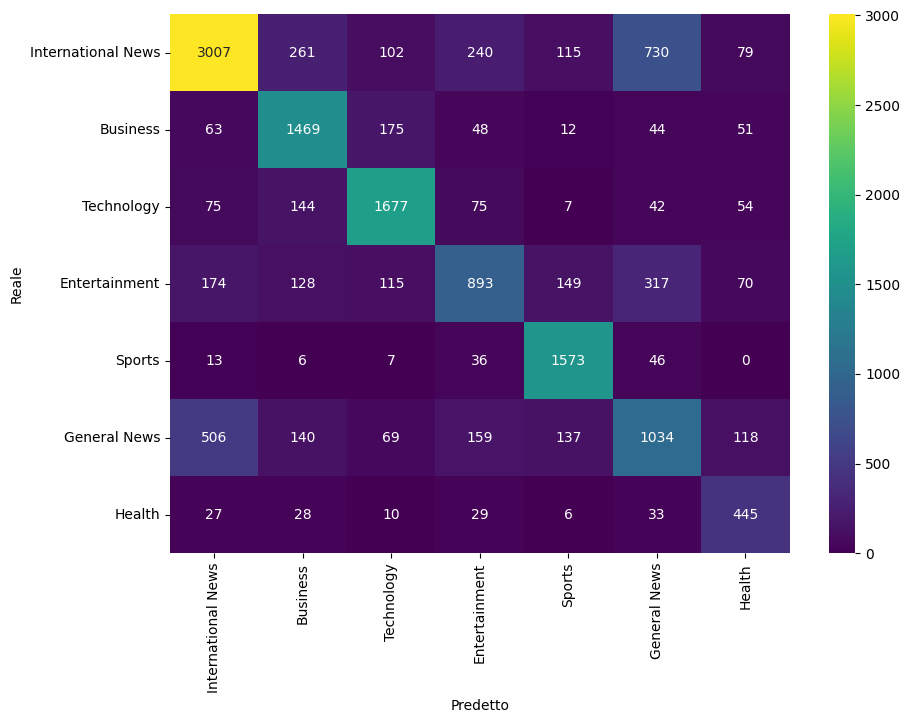

In [124]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Supponiamo che y_test siano le etichette reali e y_pred le predizioni del modello
# y_pred = model.predict(X_test)

# 1. Calcolo della matrice di confusione
cm = confusion_matrix(y_test, y_pred)
import seaborn as sns

labels = [category_map[i] for i in sorted(category_map.keys())]

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.show()

In [125]:
mask = y_test != y_pred

X_error = X_test.loc[mask == True].reset_index(drop = True)
X_error.reset_index(drop=True)
y_error = y_test[mask]
y_pred_error = y_pred[mask]

y_mapped = pd.Series(y_error).map(category_map).reset_index(drop = True)
y_mapped.name = "True_Label_Name"
y_pred_mapped = pd.Series(y_pred_error).map(category_map).reset_index(drop = True)
y_pred_mapped.name = "predicted"

prediction_errors = pd.concat([X_error, y_pred_mapped, y_mapped], axis=1)

prediction_errors.sample(10)

,Id,source,title,article,page_rank,timestamp,combined_text,combined_text2,year,article_len,predicted,True_Label_Name
3978,55191,Yahoo,ireland bans gross video game ap,ap ireland imposed its first ban wednesday on ...,5,2007-06-20 20:44:44,ireland bans gross video game ap ap ireland im...,ireland bans gross video game ap ap ireland im...,2007.0,742,Technology,International News
340,16245,Detroit,rumsfeld has eye on iraq pullout in with strings,secretary of defense donald rumsfeld said sund...,5,NaT,rumsfeld has eye on iraq pullout in with strin...,rumsfeld has eye on iraq pullout in with strin...,0.0,214,General News,Entertainment
7,10325,BBC,blackstone float set to proceed,the partial stock market listing of private eq...,5,2007-06-21 16:01:50,blackstone float set to proceed the partial st...,blackstone float set to proceed the partial st...,2007.0,112,Business,International News
2115,3720,Al-Jazeera,crowded field for palestinian election,after days of internal haggling fatah has deci...,5,2004-11-24 20:14:00,crowded field for palestinian election after d...,crowded field for palestinian election after d...,2004.0,189,General News,International News
1671,39088,New,utility will use batteries to store wind power,american electric power a coal burning utility...,5,2007-09-11 06:20:06,utility will use batteries to store wind power...,utility will use batteries to store wind power...,2007.0,175,Technology,Business
10,9115,BBC,constables raped drunk victim,two pcs raped a drunk woman after they drove h...,5,2004-10-26 17:25:45,constables raped drunk victim two pcs raped a ...,constables raped drunk victim two pcs raped a ...,2004.0,104,General News,International News
1961,54039,Crain's,columbia u professor has nose for nobel,columbia university professor richard axel wil...,5,NaT,columbia u professor has nose for nobel columb...,columbia u professor has nose for nobel columb...,0.0,184,Health,Entertainment
1624,55880,Futbolera,aragones investigation begins,luis aragon s could lose his job as spain s co...,5,NaT,aragones investigation begins luis aragon s co...,aragones investigation begins luis aragon s co...,0.0,165,Sports,Entertainment
216,71464,Yahoo,cadence design in buyout talks report reuters,reuters cadence design systems inc a maker of ...,5,2007-06-04 09:20:28,cadence design in buyout talks report reuters ...,cadence design in buyout talks report reuters ...,2007.0,204,Business,Technology
62,27342,Yahoo,doll maker fights ill recall over lead ap,ap a popular toy maker is refusing to pull a l...,5,2008-01-22 16:23:30,doll maker fights ill recall over lead ap ap a...,doll maker fights ill recall over lead ap ap a...,2008.0,167,Technology,International News


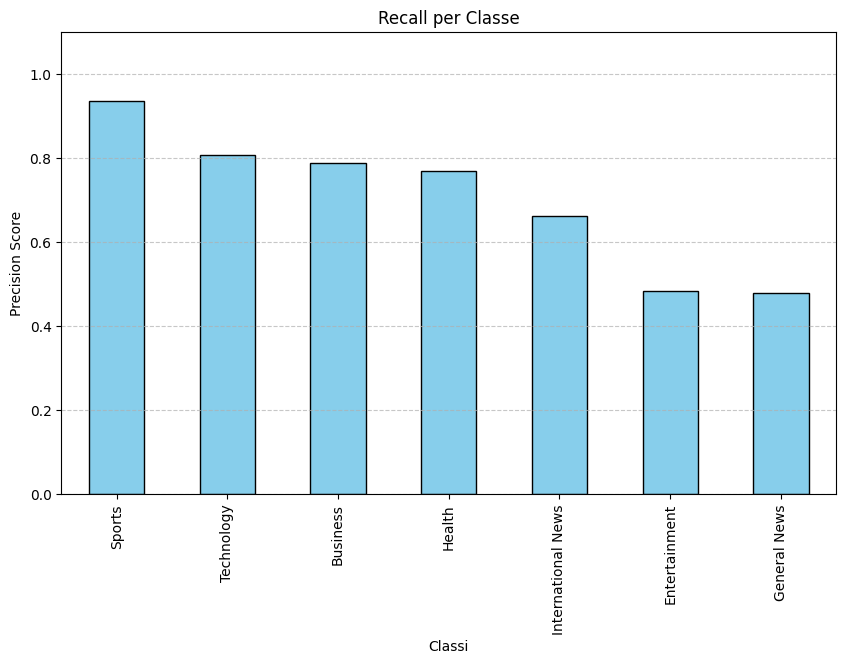

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred, target_names=labels, output_dict=True)

df_report = pd.DataFrame(report_dict).transpose()
df_recall = df_report['recall'] #recall

plt.figure(figsize=(10, 6))
df_recall.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Recall per Classe')
plt.ylabel('Recall Score')
plt.xlabel('Classi')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

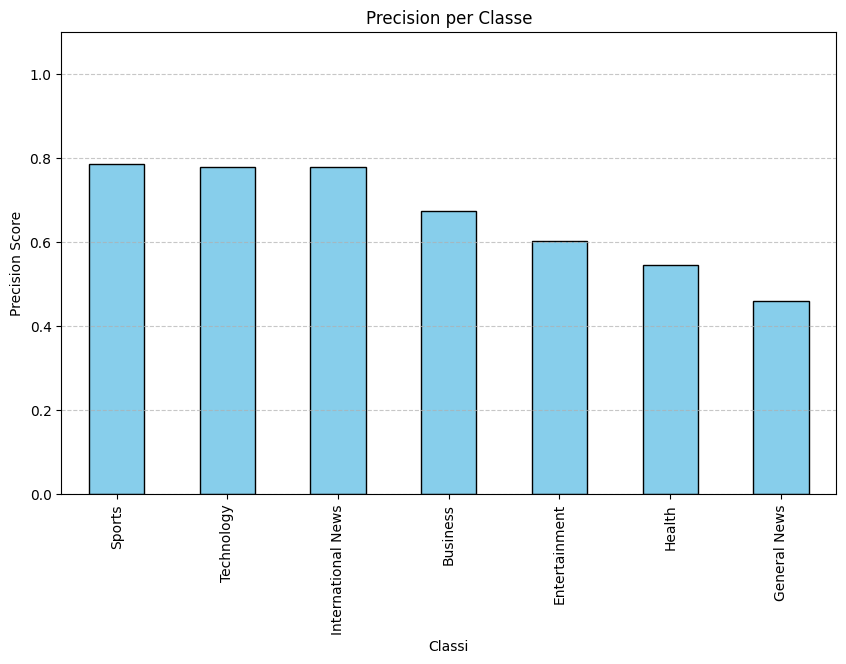

In [ ]:
# same as before to undestand precision of the model

df_precision = df_report['precision']

# 3. Plot
plt.figure(figsize=(10, 6))
df_precision.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Precision per Classe')
plt.ylabel('Precision Score')
plt.xlabel('Classi')
plt.ylim(0, 1.1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]
    
    final_pipeline.fit(X_tr, y_tr)
    pred = final_pipeline.predict(X_va)
    

    f1 = f1_score(y_va, pred, average="macro")
    scores.append(f1)
    print(f"Fold {fold + 1}: Macro-F1 = {f1:.4f}")

print("mean score", np.mean(scores))

Fold 1: Macro-F1 = 0.6867
Fold 2: Macro-F1 = 0.6820
Fold 3: Macro-F1 = 0.6805
Fold 4: Macro-F1 = 0.6779
Fold 5: Macro-F1 = 0.6883
OOF Macro-F1: 0.6830874427222262


In [ ]:
#building final model and submission.csv


evaluation = pd.read_csv('winter_project_2026/evaluation.csv')

pipe.fit(X, y)
cleaner = TextCleanerTransformer()
evaluation = cleaner.fit_transform(evaluation)
evaluation['timestamp'] = pd.to_datetime(evaluation['timestamp'], errors='coerce')
evaluation['year'] = evaluation['timestamp'].dt.year
evaluation['year'] = evaluation['year'].fillna(0)
evaluation['article_len'] = evaluation['article'].fillna('').str.len()



prediction = pipe.predict(evaluation)

results = pd.DataFrame({
    'Id': range(len(prediction)), 
    'Predicted': prediction
})

results.to_csv('submission_svm.csv', index=False)

# prossime prove

Pipeline: SelectKBest + MultinomialNB
Questa combinazione è velocissima, ideale per un solo core.

prep__selector__k: [5000, 10000, 15000, 20000] (Testiamo quanto "tagliare" il vocabolario).

clf__alpha: [0.1, 0.5, 1.0] (La "morbidezza" del modello).

clf__fit_prior: [True, False] (Se le tue classi sono sbilanciate, False aiuta molto).

text__ngram_range: [(1, 2)] (Fermati qui, i trigrammi rallentano troppo senza benefici).

text__max_df: [0.05, 0.1] (Filtra le parole troppo comuni).

Se vuoi riprovare LinearSVC (Il "salto" verso lo 0.70)
clf__C: [0.01, 0.05, 0.1] (Resta basso come abbiamo visto, per evitare l'overfitting).

clf__class_weight: ['balanced', None] (Cruciale se hai categorie con poche notizie).

clf__loss: ['hinge', 'squared_hinge'].



In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB


# list of dictionaries for each model ande Tfidf vs Count swap 
models = {
    'MultinomiaNB': {
        'params': [
            # Option 1: Using TFIDF
            {
                'clf': [MultinomialNB()],
                'clf__fit_prior': [False],
                'clf__alpha': [0.1, 0.5, 0.8],
                'preprocessor_pipeline__preprocessor__text': [TfidfVectorizer(tokenizer=lemmaTokenizer, stop_words=None, sublinear_tf=True, use_idf=True)],
                "preprocessor_pipeline__preprocessor__text__ngram_range": [(1, 2)],
                "preprocessor_pipeline__preprocessor__text__min_df": [5, 10],
                "preprocessor_pipeline__preprocessor__text__max_df": [0.08, 0.12],
                "preprocessor_pipeline__preprocessor__text__max_features": [200000],
                'preprocessor_pipeline__preprocessor__text__binary': [True, False],
                # "preprocessor_pipeline__selector__k": [1000, 10000, 50000]

                # Tuning Char-Level TFIDF (Giustificazione esclusione)
                # Impostando max_features a [0] o un valore nullo, validiamo 
                # sperimentalmente che l'apporto dei char n-grams per MNB è deleterio.
                # "preprocessor_pipeline__preprocessor__char__max_features": [0], 
                # "preprocessor_pipeline__preprocessor__char__ngram_range": [(3, 5)],
                # "preprocessor_pipeline__preprocessor__char__min_df": [5],
            },
            # Option 2: Using CountVectorizer
            # {
            #     'clf': [MultinomialNB()],
            #     'clf__fit_prior': [True, False],
            #     'clf__alpha': [0.1, 1, 0.01],
            #     'preprocessor_pipeline__preprocessor__text': [CountVectorizer(tokenizer=lemmaTokenizer, stop_words=None)],
            #     "preprocessor_pipeline__preprocessor__text__ngram_range": [(1, 2), (1, 3)],
            #     "preprocessor_pipeline__preprocessor__text__min_df": [10],
            #     "preprocessor_pipeline__preprocessor__text__max_df": [0.1, 0.05],
            #     "preprocessor_pipeline__preprocessor__text__max_features": [200_000],
            #     'preprocessor_pipeline__preprocessor__text__binary': [True, False]
            # }
        ]
    },
    # 'BernulliNB': {
    #     'params': [
    #         # Option 1: Using TFIDF
    #         {
    #             'clf': [BernoulliNB()],
    #             'clf__fit_prior': [True, False],
    #             'clf__binarize': [0.1, 0.3],
    #             'clf__alpha': [0.1, 1, 0.01],
    #             'preprocessor_pipeline__preprocessor__text': [TfidfVectorizer(tokenizer=lemmaTokenizer, stop_words=None, sublinear_tf=True, use_idf=True)],
    #             "preprocessor_pipeline__preprocessor__text__ngram_range": [(1, 2), (1, 3)],
    #             "preprocessor_pipeline__preprocessor__text__min_df": [10],
    #             "preprocessor_pipeline__preprocessor__text__max_df": [0.1, 0.05],
    #             "preprocessor_pipeline__preprocessor__text__max_features": [200_000],
    #             'preprocessor_pipeline__preprocessor__text__binary': [True, False]
    #         },
    #         # Option 2: Using CountVectorizer
    #         # {
    #         #     'clf': [BernoulliNB()],
    #         #     'clf__fit_prior': [True, False],
    #         #     'clf__binarize': [0.0, 0.1, 0.2],
    #         #     'clf__alpha': [0.1, 1, 0.01],
    #         #     'preprocessor_pipeline__preprocessor__text': [CountVectorizer(tokenizer=lemmaTokenizer, stop_words=None)],
    #         #     "preprocessor_pipeline__preprocessor__text__ngram_range": [(1, 2), (1, 3)],
    #         #     "preprocessor_pipeline__preprocessor__text__min_df": [10],
    #         #     "preprocessor_pipeline__preprocessor__text__max_df": [0.1, 0.05],
    #         #     "preprocessor_pipeline__preprocessor__text__max_features": [200_000],
    #         #     'preprocessor_pipeline__preprocessor__text__binary': [True, False]
    #         # }
    #     ]
    # }
}

cv = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=17)


best_models = {}
for model_name, config in models.items():
    print(f"Training {model_name}...")
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=config['params'],
        scoring='f1_macro',
        cv=cv,
        verbose=3
        # n_jobs=-1 
    )
    gs.fit(X, y)
    best_models[model_name] = gs.best_estimator_
    print(f"{model_name} best params: {gs.best_params_}")
    print(f"{model_name} F1 Score: {gs.best_score_:.4f}\n")

Training MultinomiaNB...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV 1/3] END clf=MultinomialNB(), clf__alpha=0.1, clf__fit_prior=False, preprocessor_pipeline__preprocessor__text=TfidfVectorizer(sublinear_tf=True,
                tokenizer=<__main__.LemmaTokenizerGood object at 0x0000018467AA1B90>), preprocessor_pipeline__preprocessor__text__binary=True, preprocessor_pipeline__preprocessor__text__max_df=0.08, preprocessor_pipeline__preprocessor__text__max_features=200000, preprocessor_pipeline__preprocessor__text__min_df=5, preprocessor_pipeline__preprocessor__text__ngram_range=(1, 2);, score=0.680 total time=  23.4s
[CV 2/3] END clf=MultinomialNB(), clf__alpha=0.1, clf__fit_prior=False, preprocessor_pipeline__preprocessor__text=TfidfVectorizer(sublinear_tf=True,
                tokenizer=<__main__.LemmaTokenizerGood object at 0x0000018467AA1B90>), preprocessor_pipeline__preprocessor__text__binary=True, preprocessor_pipeline__preprocessor__text__max_df=0.08, prepro

In [131]:
print(gs.best_params_)
print(gs.best_score_)

{'clf': MultinomialNB(), 'clf__alpha': 0.5, 'clf__fit_prior': False, 'preprocessor_pipeline__preprocessor__text': TfidfVectorizer(sublinear_tf=True,
                tokenizer=<__main__.LemmaTokenizerGood object at 0x0000018467AA1B90>), 'preprocessor_pipeline__preprocessor__text__binary': False, 'preprocessor_pipeline__preprocessor__text__max_df': 0.08, 'preprocessor_pipeline__preprocessor__text__max_features': 200000, 'preprocessor_pipeline__preprocessor__text__min_df': 10, 'preprocessor_pipeline__preprocessor__text__ngram_range': (1, 2)}
0.6852729973713899


# {'clf': MultinomialNB(), 'clf__alpha': 0.5, 'clf__fit_prior': False, 'preprocessor_pipeline__preprocessor__text': TfidfVectorizer(sublinear_tf=True, tokenizer=<__main__.LemmaTokenizerGood object at 0x00000152ED99CB90>), 'preprocessor_pipeline__preprocessor__text__binary': False, 'preprocessor_pipeline__preprocessor__text__max_df': 0.12, 'preprocessor_pipeline__preprocessor__text__max_features': 200000, 'preprocessor_pipeline__preprocessor__text__min_df': 10, 'preprocessor_pipeline__preprocessor__text__ngram_range': (1, 2)}
0.6859996474993489

In [ ]:
final_pipeline = best_models['MultinomiaNB']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

print(f1_score(y_pred, y_test, average='macro'))

evaluation = pd.read_csv('winter_project_2026/evaluation.csv')

final_pipeline.fit(X, y)
cleaner = TextCleanerTransformer()
evaluation = cleaner.fit_transform(evaluation)
evaluation['timestamp'] = pd.to_datetime(evaluation['timestamp'], errors='coerce')
evaluation['year'] = evaluation['timestamp'].dt.year
evaluation['year'] = evaluation['year'].fillna(0)
evaluation['article_len'] = evaluation['article'].fillna('').str.len()
prediction = final_pipeline.predict(evaluation)

results = pd.DataFrame({
    'Id': range(len(prediction)), 
    'Predicted': prediction
})

results.to_csv('submission_bayesian_best_params.csv', index=False)

0.6764820585197633
